# Import Required Libraries and Functions
First, we import the necessary packages and replicate the data loading and splitting logic from the `train.py` script.

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, roc_curve, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Define functions from train.py
def load_and_prepare_data(path, target_horizon=1, target_window=3, num_lags=3):
    df = pd.read_parquet(path)
    df.reset_index(inplace=True)
    df = df.sort_values(['stay_id', 'timestep'])
    if num_lags > 0:
        features_to_lag = [c for c in df.columns if c not in ['stay_id', 'timestep', 'sepsis']]
        for lag in range(1, num_lags + 1):
            for col in features_to_lag:
                df[f'{col}_lag{lag}'] = df.groupby('stay_id')[col].shift(lag)
                df[f'{col}_diff{lag}'] = df[col] - df[f'{col}_lag{lag}']
    subset_cols = [c for c in df.columns if c not in ['stay_id', 'timestep', 'sepsis'] and len(df[f'{c}'].dropna()) > 0]
    
    targets = []
    for w in range(target_window):
        targets.append(df.groupby('stay_id')['sepsis'].shift(-(target_horizon + w)))
    df['target'] = pd.concat(targets, axis=1).max(axis=1)
    
    df = df[df['sepsis'] == 0].copy()
    df['target'] = (df['target'].fillna(0) >= 1).astype(int)
    return df

def grouped_stratified_split(df, train_frac=0.70, val_frac=0.15, test_frac=0.15, random_state=42):
    patient_outcomes = df.groupby('stay_id')['target'].max().reset_index()
    stay_ids = patient_outcomes['stay_id'].values
    y_patient = patient_outcomes['target'].values
    ids_train, ids_tmp, y_train, y_tmp = train_test_split(
        stay_ids, y_patient, stratify=y_patient, test_size=(val_frac + test_frac), random_state=random_state
    )
    rel_test_frac = test_frac / (val_frac + test_frac)
    ids_val, ids_test = train_test_split(
        ids_tmp, stratify=y_tmp, test_size=rel_test_frac, random_state=random_state
    )
    df_train = df[df['stay_id'].isin(ids_train)].copy()
    df_val = df[df['stay_id'].isin(ids_val)].copy()
    df_test = df[df['stay_id'].isin(ids_test)].copy()
    return df_train, df_val, df_test

# Load Data and Split
Next, we load the dataset and prepare our training, validation, and testing sets exactly as done during training.

In [ ]:
path = '../../data/processed_files/patient_timeseries_cleaned.parquet'

df = load_and_prepare_data(path, target_horizon=1, target_window=3, num_lags=3)

df_train, df_val, df_test = grouped_stratified_split(df)

drop_cols = ['stay_id', 'timestep', 'sepsis', 'target']
features = [c for c in df.columns if c not in drop_cols]

X_train = df_train[features]
y_train = df_train['target']
X_val = df_val[features]
y_val = df_val['target']
X_test = df_test[features]
y_test = df_test['target']

print(f"Test Set Size: {len(X_test)} rows")

Test Set Size: 135017 rows


# Train LightGBM with Best Hyperparameters
Here we take the best parameters discovered during the Optuna run and train the model.

In [30]:
best_params ={
    'learning_rate': 0.030621496413890132, 
    'num_leaves': 12, 
    'max_depth': 9, 
    'min_child_samples': 46, 
    'subsample': 0.7224702134727826, 
    'colsample_bytree': 0.8795139833300994, 
    'scale_pos_weight': 36.46069848330612, 
    'n_estimators': 654,
    'objective': 'binary',
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}


final_lgb = lgb.LGBMClassifier(**best_params)
final_lgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

,boosting_type,'gbdt'
,num_leaves,12
,max_depth,9
,learning_rate,0.030621496413890132
,n_estimators,654
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,46


# Test Predictions
We make predictions on `X_test` and reattach `stay_id` and `timestep` from the original test dataframe.

In [31]:
y_probs_test = final_lgb.predict_proba(X_test)[:, 1]

# Reconstruct a DataFrame with the necessary identifiers and predictions
results_df = df_test[['stay_id', 'timestep', 'target']].copy()
results_df['predicted_prob'] = y_probs_test

results_df.head()

,stay_id,timestep,target,predicted_prob
143,30001471,1,0,0.063274
144,30001471,2,0,0.037303
145,30001471,3,0,0.037303
146,30001471,4,0,0.045050
147,30001471,5,0,0.057323


In [32]:
# --- Suggestion 1: Tune Threshold ---
precs, recs, threshs = precision_recall_curve(y_test, y_probs_test)
f1_scores = 2 * (precs * recs) / (precs + recs + 1e-10)
optimal_idx = np.argmax(f1_scores)
best_threshold = threshs[optimal_idx] if optimal_idx < len(threshs) else 0.5

print(f"Optimal Threshold (Max F1): {best_threshold:.4f}")

# Apply predictions using the optimal threshold
results_df['prediction'] = (results_df['predicted_prob'] >= best_threshold).astype(int)
results_df.head()

Optimal Threshold (Max F1): 0.0576


,stay_id,timestep,target,predicted_prob,prediction
143,30001471,1,0,0.063274,1
144,30001471,2,0,0.037303,0
145,30001471,3,0,0.037303,0
146,30001471,4,0,0.045050,0
147,30001471,5,0,0.057323,0


# Calculate Metrics per Timestep
We will now evaluate AUPRC and AUROC individually for each discrete timestep the model made predictions for.

*Note: For the metrics to be valid, each timestep's group must contain at least one positive and one negative sample. If a timestep doesn't have both, the AUPRC/AUROC cannot be calculated and we skip it.*

In [33]:
timestep_metrics = []

for t_val, group in results_df.groupby('timestep'):
    # Check if there's at least one positive and one negative sample to calculate ROC/PR curves
    if group['target'].nunique() > 1:
        auprc = average_precision_score(group['target'], group['predicted_prob'])
        auroc = roc_auc_score(group['target'], group['predicted_prob'])
        
        # We can also calculate some class imbalance metrics for context
        total = len(group)
        positives = group['target'].sum()
        negatives = total - positives
        
        timestep_metrics.append({
            'timestep': t_val,
            'auprc': auprc,
            'auroc': auroc,
            'positives': positives,
            'negatives': negatives,
            'total_samples': total
        })

metrics_df = pd.DataFrame(timestep_metrics)
metrics_df = metrics_df[metrics_df['total_samples'] >= 30] # Filter out timesteps with too few total samples to be trustworthy 

metrics_df.head()

,timestep,auprc,auroc,positives,negatives,total_samples
0,1,0.088380,0.563110,907,10874,11781
1,2,0.101544,0.623531,777,10093,10870
2,3,0.053927,0.589468,426,9650,10076
3,4,0.046509,0.626961,288,9315,9603
4,5,0.047309,0.621709,299,8941,9240


# Visualizations
Finally, generate plots visualizing the model's performance as patient timesteps progress.

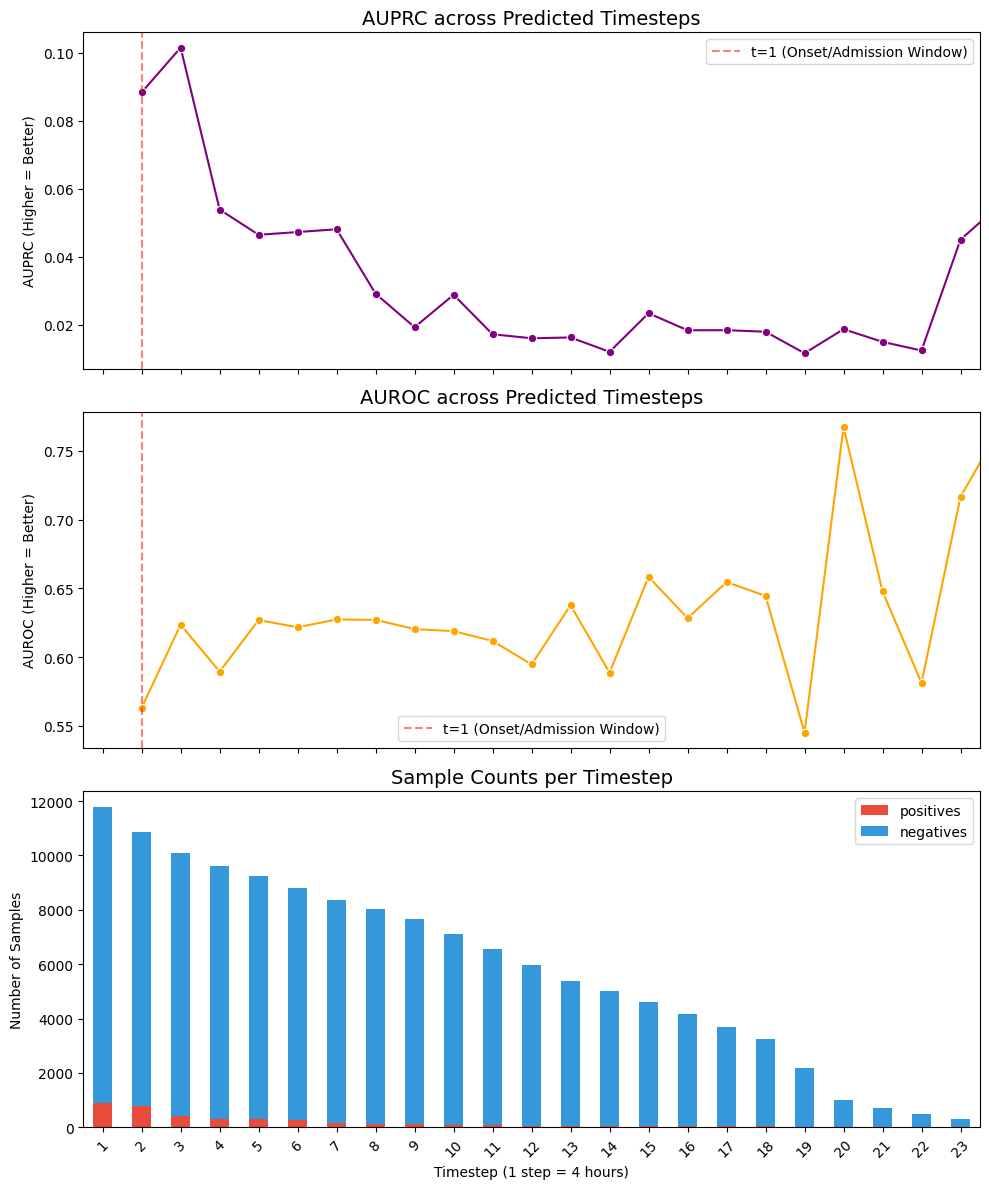

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Define upper limit of timesteps to plot (since very long stays have few samples)
plot_df = metrics_df.copy()

# AUPRC Plot
sns.lineplot(ax=axes[0], data=plot_df, x='timestep', y='auprc', marker='o', color='purple')
axes[0].axvline(1, color='red', linestyle='--', alpha=0.5, label='t=1 (Onset/Admission Window)')
axes[0].set_title('AUPRC across Predicted Timesteps', fontsize=14)
axes[0].set_ylabel('AUPRC (Higher = Better)')
axes[0].legend()

# AUROC Plot
sns.lineplot(ax=axes[1], data=plot_df, x='timestep', y='auroc', marker='o', color='orange')
axes[1].axvline(1, color='red', linestyle='--', alpha=0.5, label='t=1 (Onset/Admission Window)')
axes[1].set_title('AUROC across Predicted Timesteps', fontsize=14)
axes[1].set_ylabel('AUROC (Higher = Better)')
axes[1].legend()

# Distribution context (pos/neg per group)
plot_df.set_index('timestep')[['positives', 'negatives']].plot(
    kind='bar', stacked=True, ax=axes[2], color=['#e74c3c', '#3498db']
)
axes[2].set_title('Sample Counts per Timestep', fontsize=14)
axes[2].set_ylabel('Number of Samples')
axes[2].set_xlabel('Timestep (1 step = 4 hours)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

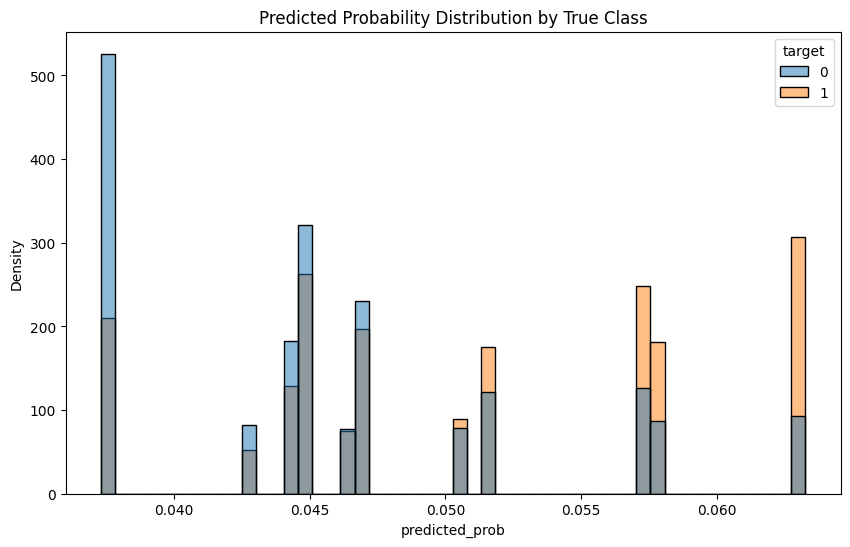

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(data=results_df, x='predicted_prob', hue='target', bins=50, stat='density', common_norm=False)
plt.title('Predicted Probability Distribution by True Class')
plt.show()

Confusion Matrix with Optimal Threshold:
True Positives: 980 | False Positives: 12194
False Negatives: 2891 | True Negatives: 118952
Recall: 0.2532
Precision: 0.0744

We have 2891 False Negatives (missed sepsis cases).


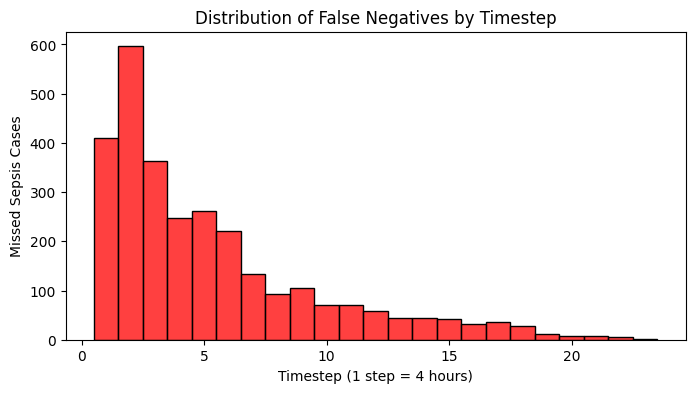

In [36]:
# --- Suggestion 4: Error Analysis ---
print("Confusion Matrix with Optimal Threshold:")
tp = ((results_df['target'] == 1) & (results_df['prediction'] == 1)).sum()
tn = ((results_df['target'] == 0) & (results_df['prediction'] == 0)).sum()
fp = ((results_df['target'] == 0) & (results_df['prediction'] == 1)).sum()
fn = ((results_df['target'] == 1) & (results_df['prediction'] == 0)).sum()

print(f"True Positives: {tp} | False Positives: {fp}")
print(f"False Negatives: {fn} | True Negatives: {tn}")
print(f"Recall: {tp / (tp + fn):.4f}" if (tp + fn) > 0 else "Recall: undefined")
print(f"Precision: {tp / (tp + fp):.4f}" if (tp + fp) > 0 else "Precision: undefined")

# Investigate False Negatives (Missed Sepsis Cases)
fn_df = results_df[(results_df['target'] == 1) & (results_df['prediction'] == 0)]
print(f"\nWe have {len(fn_df)} False Negatives (missed sepsis cases).")

# Plot when these False Negatives occur
plt.figure(figsize=(8, 4))
sns.histplot(fn_df['timestep'], color='red', discrete = True)
plt.title("Distribution of False Negatives by Timestep")
plt.xlabel("Timestep (1 step = 4 hours)")
plt.ylabel("Missed Sepsis Cases")
plt.show()

# --- Supervisor's Request: Feature Importance and Correlation ---
First, we'll plot the built-in Feature Importance from the LightGBM model, similar to the XGBoost plot provided.

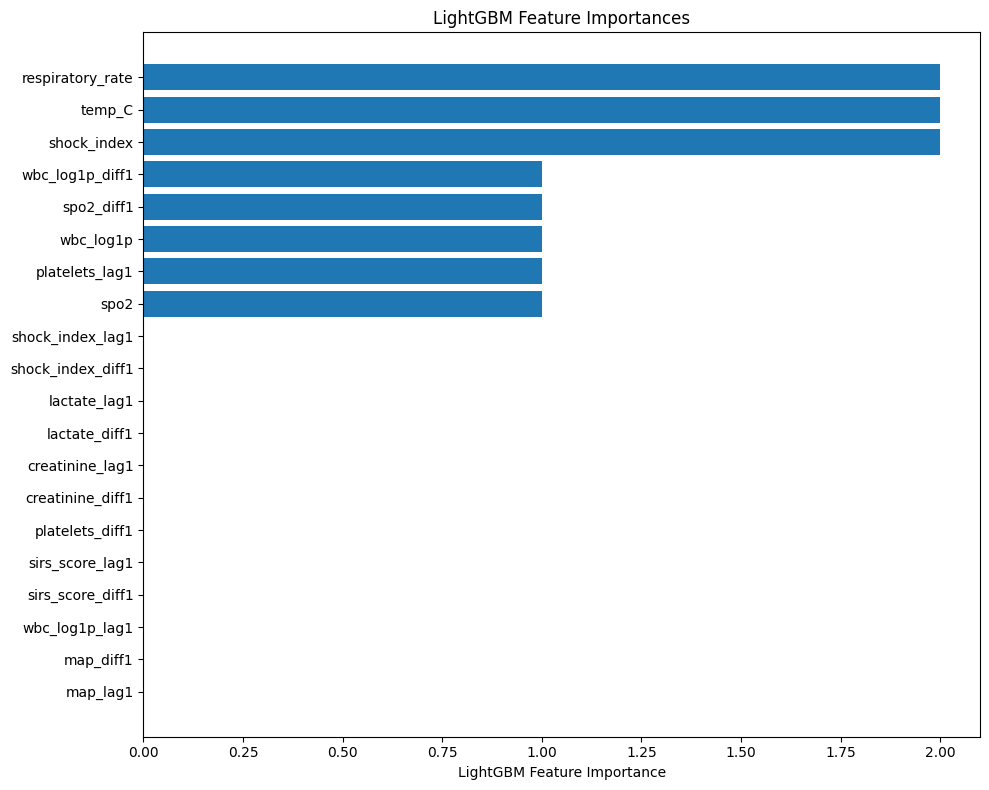

In [37]:
# Plot LightGBM built-in feature importance (Top 25 features for readability)
plt.figure(figsize=(10, 8))

# Get feature importances and sort them
importances = final_lgb.feature_importances_
sorted_idx = importances.argsort()[-20:]

# Plotting
plt.barh(X_train.columns[sorted_idx], importances[sorted_idx])
plt.xlabel("LightGBM Feature Importance")
plt.title("LightGBM Feature Importances")
plt.tight_layout()
plt.show()

Next, we'll plot the correlation between the input features and the `target` variable. This helps identify linear relationships and confirms how noisy the individual features are with respect to predicting sepsis.

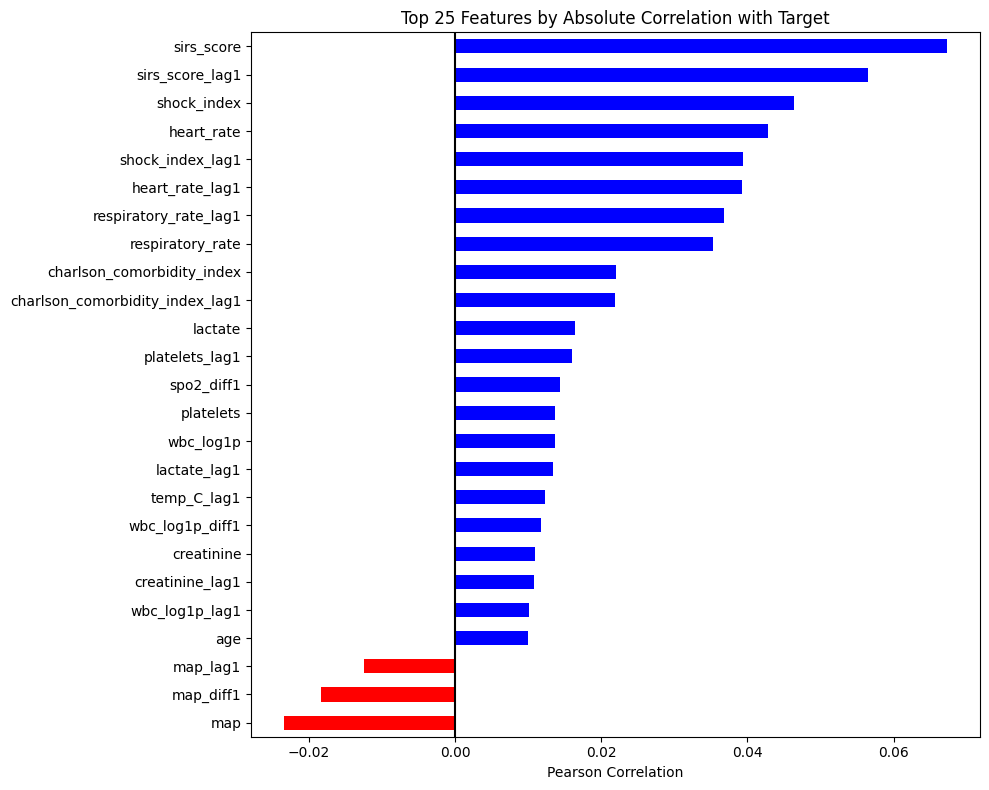

In [38]:
# Plot correlation between top features and the target variable
plt.figure(figsize=(10, 8))

# We'll calculate the correlation on the training data
df_corr = X_train.copy()
df_corr['target'] = y_train

# Calculate Pearson correlation with the target
correlations = df_corr.corr()['target'].drop('target')

# Sort by absolute correlation to find the strongest signals (positive or negative)
correlations_sorted = correlations.abs().sort_values(ascending=False)

# Get the top 25 most correlated features
top_25_corr = correlations[correlations_sorted.index[:25]].sort_values()

# Plotting
colors = ['red' if val < 0 else 'blue' for val in top_25_corr]
top_25_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black')
plt.xlabel("Pearson Correlation")
plt.title("Top 25 Features by Absolute Correlation with Target")
plt.tight_layout()
plt.show()